In [7]:
# Cell 1: Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Display settings - makes output cleaner
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

# Plot style - makes charts look professional
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [8]:
# Cell 2: Load the California Housing Dataset
housing = fetch_california_housing(as_frame=True)

# Combine features and target into one DataFrame
df = housing.frame

print(f"✅ Dataset loaded successfully")
print(f"📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")

✅ Dataset loaded successfully
📊 Shape: 20640 rows × 9 columns


In [9]:
# Cell 3: First look at the data
print("=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print("LAST 5 ROWS")
print("=" * 60)
display(df.tail())

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df.dtypes)

FIRST 5 ROWS


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.33,41.00,6.98,1.02,322.00,2.56,37.88,-122.23,4.53
1,8.30,21.00,6.24,0.97,2401.00,2.11,37.86,-122.22,3.58
2,7.26,52.00,8.29,1.07,496.00,2.80,37.85,-122.24,3.52
3,5.64,52.00,5.82,1.07,558.00,2.55,37.85,-122.25,3.41
4,3.85,52.00,6.28,1.08,565.00,2.18,37.85,-122.25,3.42



LAST 5 ROWS


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20635,1.56,25.00,5.05,1.13,845.00,2.56,39.48,-121.09,0.78
20636,2.56,18.00,6.11,1.32,356.00,3.12,39.49,-121.21,0.77
20637,1.70,17.00,5.21,1.12,1007.00,2.33,39.43,-121.22,0.92
20638,1.87,18.00,5.33,1.17,741.00,2.12,39.43,-121.32,0.85
20639,2.39,16.00,5.25,1.16,1387.00,2.62,39.37,-121.24,0.89



DATA TYPES
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


In [10]:
# Cell 4: Understanding every column
column_descriptions = {
    'MedInc':       'Median income of households in the block (in tens of thousands of USD)',
    'HouseAge':     'Median age of houses in the block (in years)',
    'AveRooms':     'Average number of rooms per household',
    'AveBedrms':    'Average number of bedrooms per household',
    'Population':   'Total population in the block',
    'AveOccup':     'Average number of household members',
    'Latitude':     'Geographic latitude of the block',
    'Longitude':    'Geographic longitude of the block',
    'MedHouseVal':  '🎯 TARGET: Median house value (in hundreds of thousands of USD)'
}

print("=" * 60)
print("COLUMN-BY-COLUMN EXPLANATION")
print("=" * 60)
for col, desc in column_descriptions.items():
    print(f"\n📌 {col}")
    print(f"   → {desc}")

COLUMN-BY-COLUMN EXPLANATION

📌 MedInc
   → Median income of households in the block (in tens of thousands of USD)

📌 HouseAge
   → Median age of houses in the block (in years)

📌 AveRooms
   → Average number of rooms per household

📌 AveBedrms
   → Average number of bedrooms per household

📌 Population
   → Total population in the block

📌 AveOccup
   → Average number of household members

📌 Latitude
   → Geographic latitude of the block

📌 Longitude
   → Geographic longitude of the block

📌 MedHouseVal
   → 🎯 TARGET: Median house value (in hundreds of thousands of USD)


In [11]:
# Cell 5: Statistical summary
print("=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
display(df.describe())

print("\n📌 KEY THINGS TO NOTICE:")
print(f"  • Target (MedHouseVal) range: {df['MedHouseVal'].min():.2f} → {df['MedHouseVal'].max():.2f}")
print(f"  • Average house value: ${df['MedHouseVal'].mean() * 100_000:,.0f}")
print(f"  • AveRooms max: {df['AveRooms'].max():.1f}  ← possible outlier!")
print(f"  • AveBedrms max: {df['AveBedrms'].max():.1f}  ← possible outlier!")
print(f"  • AveOccup max: {df['AveOccup'].max():.1f}  ← possible outlier!")

STATISTICAL SUMMARY


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00



📌 KEY THINGS TO NOTICE:
  • Target (MedHouseVal) range: 0.15 → 5.00
  • Average house value: $206,856
  • AveRooms max: 141.9  ← possible outlier!
  • AveBedrms max: 34.1  ← possible outlier!
  • AveOccup max: 1243.3  ← possible outlier!


In [12]:
# Cell 6: Missing values analysis
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print(missing_df)
print(f"\n✅ Total missing values: {df.isnull().sum().sum()}")

if df.isnull().sum().sum() == 0:
    print("✅ Great news — no missing values in this dataset!")
else:
    print("⚠️  Missing values found — must handle in preprocessing!")

MISSING VALUES ANALYSIS
             Missing Count  Missing %
MedInc                   0       0.00
HouseAge                 0       0.00
AveRooms                 0       0.00
AveBedrms                0       0.00
Population               0       0.00
AveOccup                 0       0.00
Latitude                 0       0.00
Longitude                0       0.00
MedHouseVal              0       0.00

✅ Total missing values: 0
✅ Great news — no missing values in this dataset!


In [13]:
# Cell 7: Duplicate rows check
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

if duplicates == 0:
    print("✅ No duplicate rows found.")
else:
    print(f"⚠️  Found {duplicates} duplicate rows — will remove in preprocessing.")

Duplicate rows found: 0
✅ No duplicate rows found.


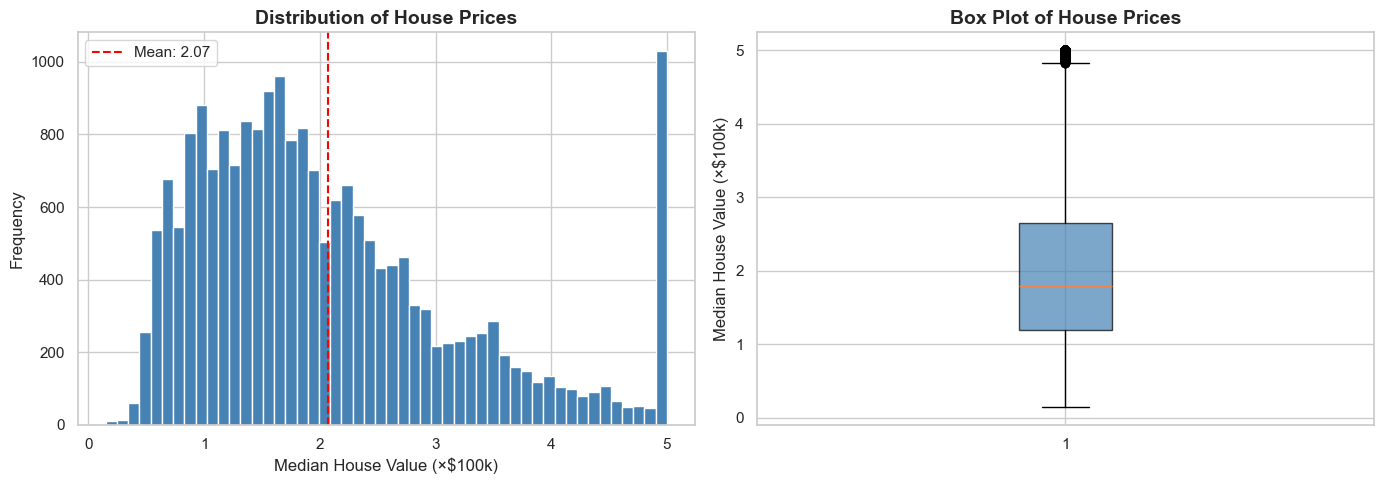


📌 Skewness: 0.9778
   → Skewness > 1 means right-skewed (many cheap houses, few very expensive ones)
   → We may apply log transformation in preprocessing to fix this


In [16]:
# Cell 8: Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of House Prices', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Median House Value (×$100k)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['MedHouseVal'].mean(), color='red',
                linestyle='--', label=f"Mean: {df['MedHouseVal'].mean():.2f}")
axes[0].legend()

# Box plot
axes[1].boxplot(df['MedHouseVal'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Box Plot of House Prices', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Median House Value (×$100k)')

plt.tight_layout()
plt.savefig('../assets/screenshots/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📌 Skewness: {df['MedHouseVal'].skew():.4f}")
print("   → Skewness > 1 means right-skewed (many cheap houses, few very expensive ones)")
print("   → We may apply log transformation in preprocessing to fix this")

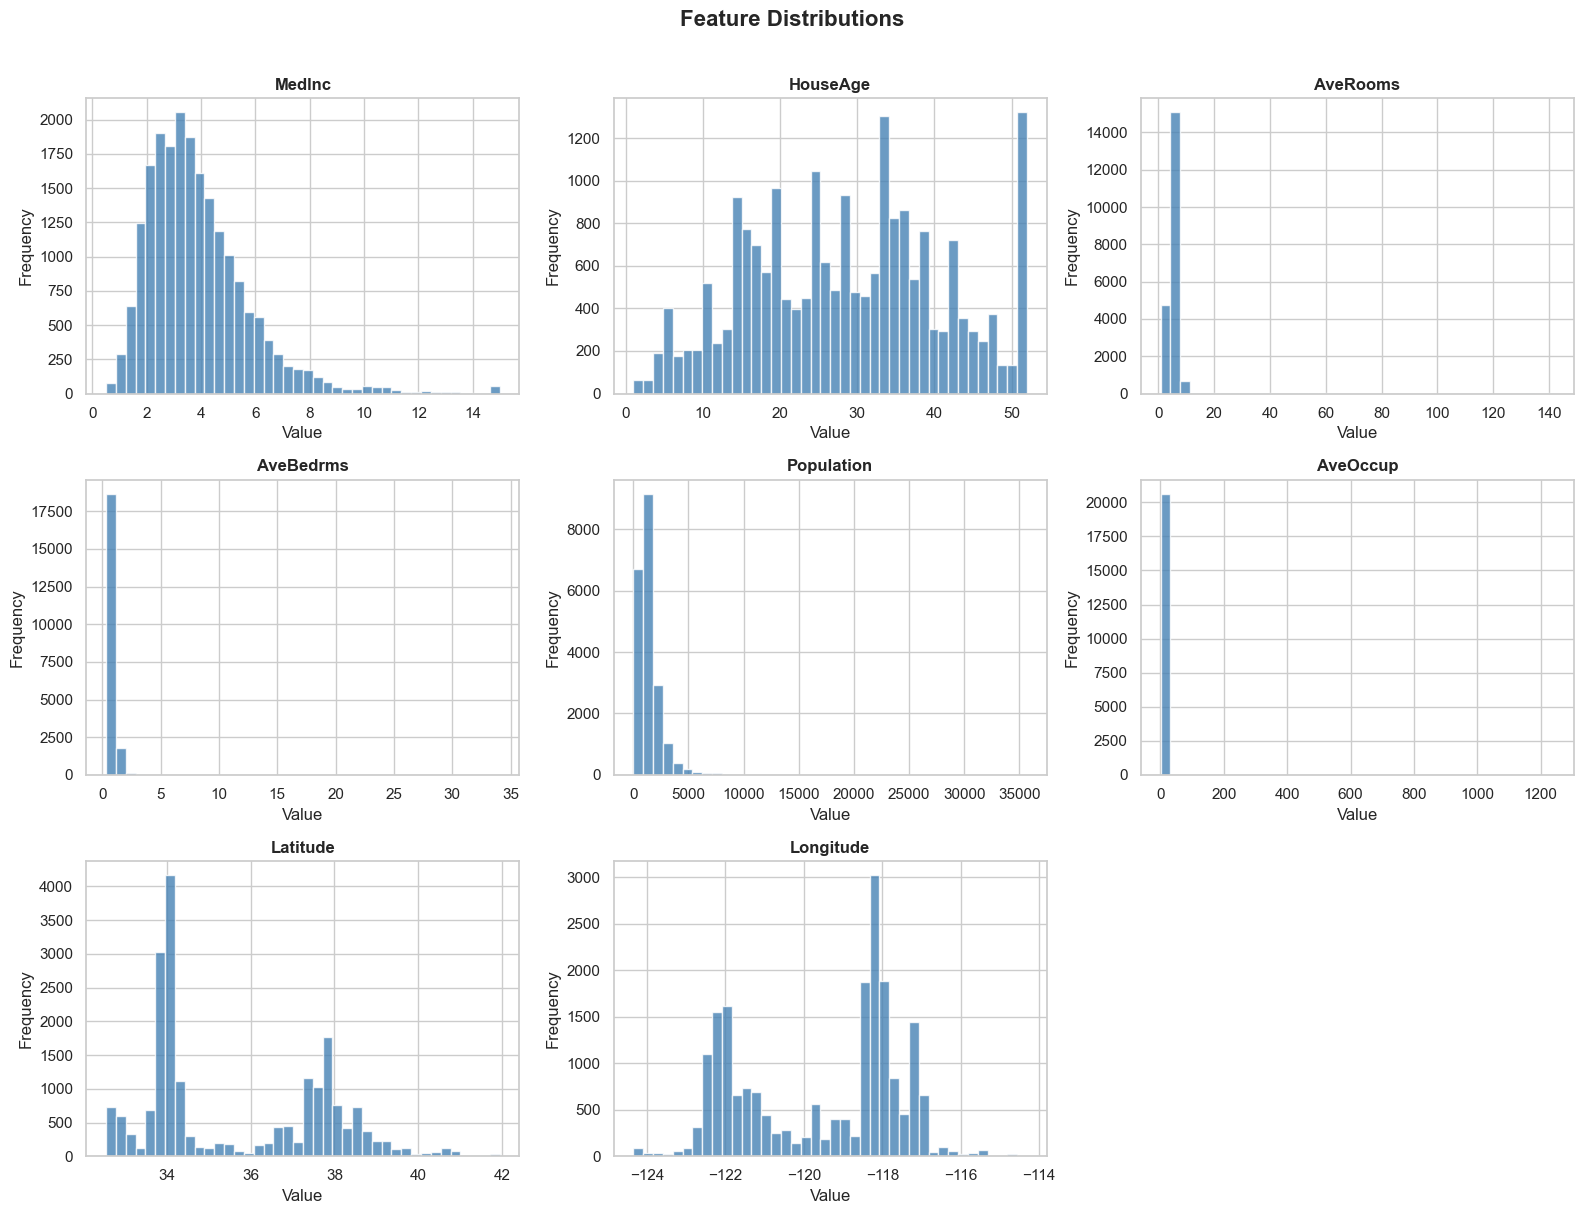

In [17]:
# Cell 9: Distribution of all features
features = [col for col in df.columns if col != 'MedHouseVal']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df[feature], bins=40, color='steelblue',
                 edgecolor='white', alpha=0.8)
    axes[i].set_title(feature, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Hide the last empty subplot if features < 9
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../assets/screenshots/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Cell 10: Outlier detection using IQR method
print("=" * 60)
print("OUTLIER DETECTION (IQR Method)")
print("=" * 60)
print("Rule: Values below Q1 - 1.5×IQR or above Q3 + 1.5×IQR are outliers\n")

outlier_summary = []

for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_pct = (outlier_count / len(df)) * 100
    outlier_summary.append({
        'Column': col,
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Outlier Count': outlier_count,
        'Outlier %': round(outlier_pct, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df.sort_values('Outlier %', ascending=False))

OUTLIER DETECTION (IQR Method)
Rule: Values below Q1 - 1.5×IQR or above Q3 + 1.5×IQR are outliers



,Column,Lower Bound,Upper Bound,Outlier Count,Outlier %
3,AveBedrms,0.87,1.24,1424,6.90
4,Population,-620.00,3132.00,1196,5.79
8,MedHouseVal,-0.98,4.82,1071,5.19
5,AveOccup,1.15,4.56,711,3.44
0,MedInc,-0.71,8.01,681,3.30
2,AveRooms,2.02,8.47,511,2.48
1,HouseAge,-10.50,65.50,0,0.00
6,Latitude,28.26,43.38,0,0.00
7,Longitude,-127.48,-112.33,0,0.00


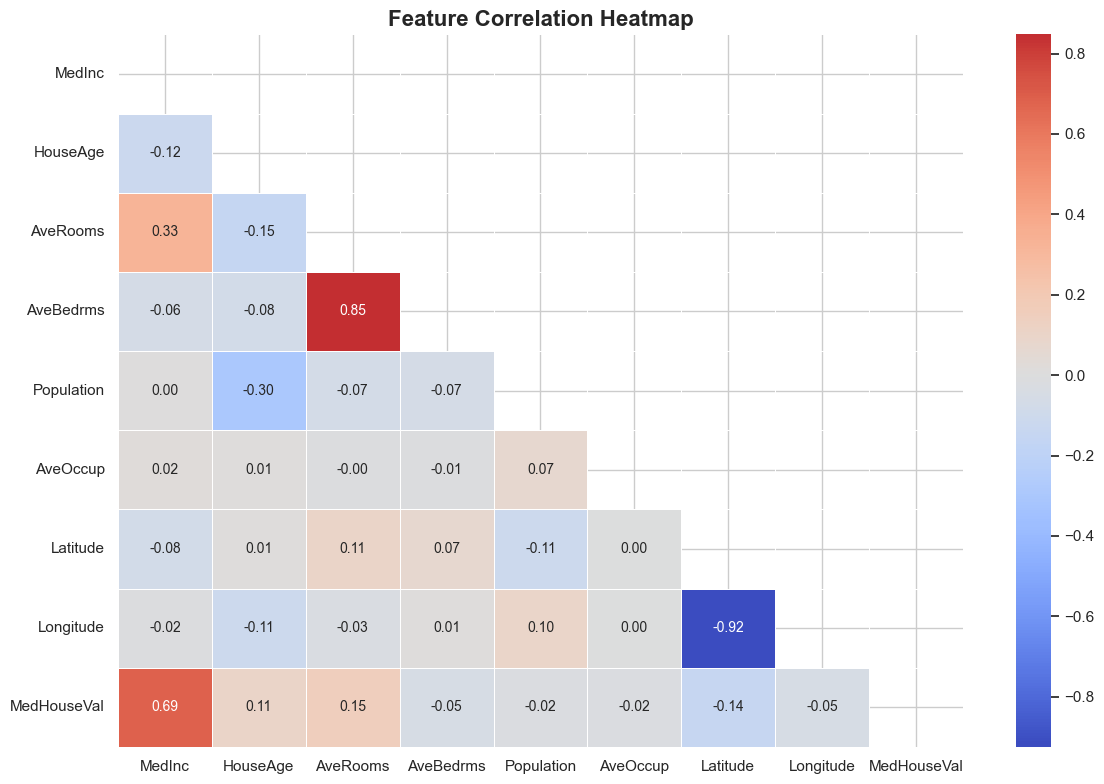


📌 CORRELATION WITH TARGET (MedHouseVal):
  MedInc          +0.688  █████████████ ↑ positive
  AveRooms        +0.152  ███ ↑ positive
  HouseAge        +0.106  ██ ↑ positive
  AveOccup        -0.024   ↓ negative
  Population      -0.025   ↓ negative
  Longitude       -0.046   ↓ negative
  AveBedrms       -0.047   ↓ negative
  Latitude        -0.144  ██ ↓ negative


In [19]:
# Cell 11: Correlation heatmap
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 10}
)

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/screenshots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 CORRELATION WITH TARGET (MedHouseVal):")
target_corr = corr_matrix['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False)
for feat, val in target_corr.items():
    bar = "█" * int(abs(val) * 20)
    direction = "↑ positive" if val > 0 else "↓ negative"
    print(f"  {feat:<15} {val:+.3f}  {bar} {direction}")

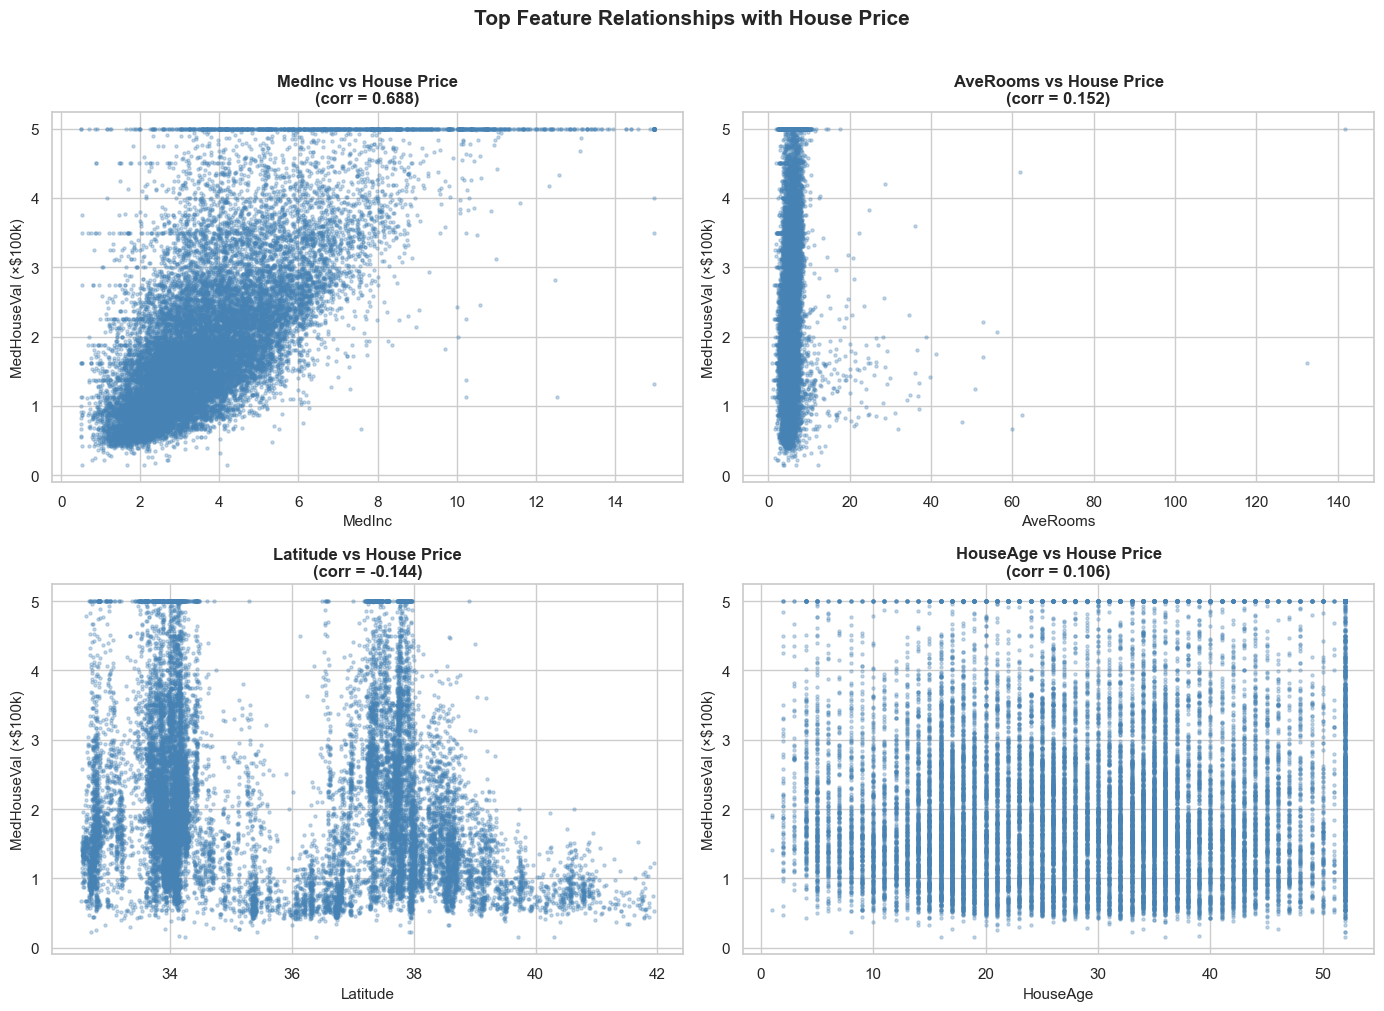

In [20]:
# Cell 12: Scatter plots of top correlated features vs target
top_features = target_corr.abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    axes[i].scatter(df[feature], df['MedHouseVal'],
                    alpha=0.3, color='steelblue', s=5)
    axes[i].set_xlabel(feature, fontsize=11)
    axes[i].set_ylabel('MedHouseVal (×$100k)', fontsize=11)
    axes[i].set_title(f'{feature} vs House Price\n'
                      f'(corr = {corr_matrix.loc[feature, "MedHouseVal"]:.3f})',
                      fontsize=12, fontweight='bold')

plt.suptitle('Top Feature Relationships with House Price',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../assets/screenshots/scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

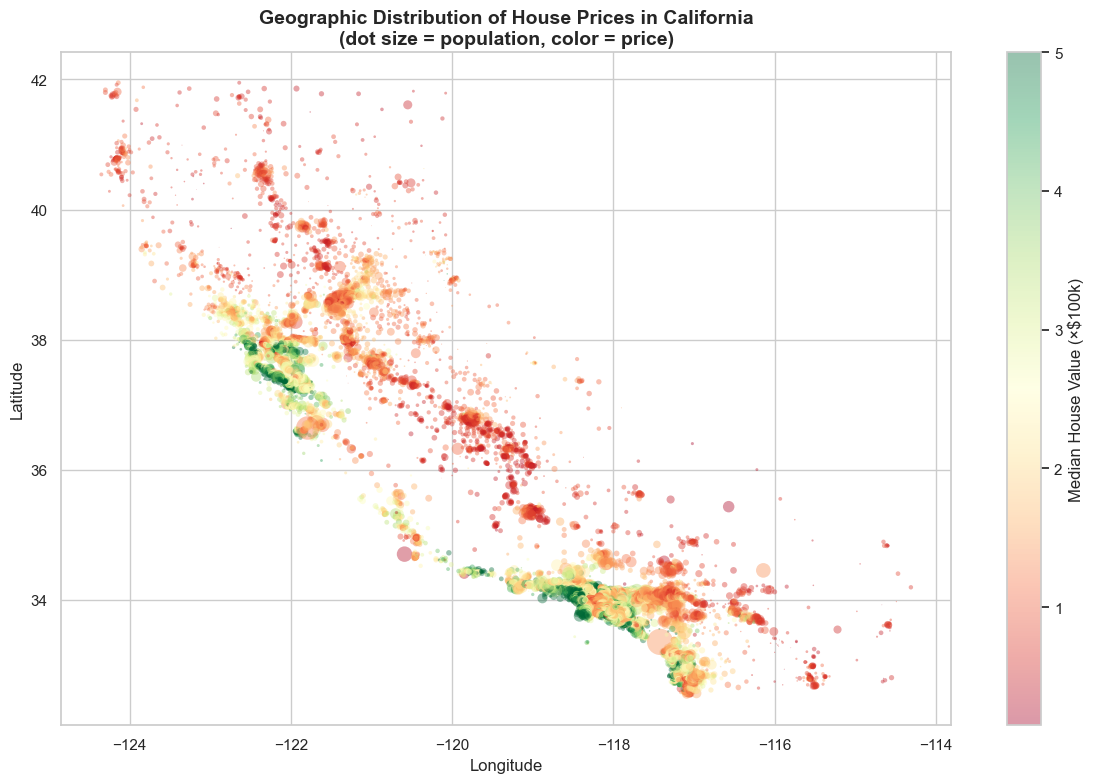

📌 You can clearly see:
   • Coastal cities (San Francisco, LA) = Higher prices (green)
   • Inland areas = Lower prices (red)
   • This means Latitude & Longitude are important features!


In [21]:
# Cell 13: Geographic visualization of house prices
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    df['Longitude'],
    df['Latitude'],
    c=df['MedHouseVal'],
    cmap='RdYlGn',
    alpha=0.4,
    s=df['Population'] / 100,   # dot size = population
    linewidths=0
)

plt.colorbar(scatter, label='Median House Value (×$100k)')
plt.title('Geographic Distribution of House Prices in California\n'
          '(dot size = population, color = price)',
          fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.savefig('../assets/screenshots/geo_map.png', dpi=150, bbox_inches='tight')
plt.show()

print("📌 You can clearly see:")
print("   • Coastal cities (San Francisco, LA) = Higher prices (green)")
print("   • Inland areas = Lower prices (red)")
print("   • This means Latitude & Longitude are important features!")

In [22]:
# Cell 14: EDA Summary & findings
print("""
╔══════════════════════════════════════════════════════════╗
║              EDA SUMMARY & KEY FINDINGS                  ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Dataset:  20,640 rows × 9 columns                       ║
║  Target:   MedHouseVal (Median House Value ×$100k)       ║
║                                                          ║
║  ✅ No missing values found                              ║
║  ✅ No duplicate rows found                              ║
║                                                          ║
║  ⚠️  OUTLIERS DETECTED in:                               ║
║     • AveRooms, AveBedrms, AveOccup, Population         ║
║     → Will be handled in Phase 3 (Preprocessing)        ║
║                                                          ║
║  📊 TARGET DISTRIBUTION:                                 ║
║     → Right-skewed                                       ║
║     → Values capped at 5.0 (data collection artifact)   ║
║     → Log transformation recommended                    ║
║                                                          ║
║  🔑 STRONGEST PREDICTORS of price:                       ║
║     1. MedInc     (income → strongest signal)            ║
║     2. Latitude   (location matters)                     ║
║     3. Longitude  (location matters)                     ║
║     4. HouseAge   (moderate effect)                      ║
║                                                          ║
║  📌 NEXT STEP: Phase 3 - Data Preprocessing              ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║              EDA SUMMARY & KEY FINDINGS                  ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Dataset:  20,640 rows × 9 columns                       ║
║  Target:   MedHouseVal (Median House Value ×$100k)       ║
║                                                          ║
║  ✅ No missing values found                              ║
║  ✅ No duplicate rows found                              ║
║                                                          ║
║  ⚠️  OUTLIERS DETECTED in:                               ║
║     • AveRooms, AveBedrms, AveOccup, Population         ║
║     → Will be handled in Phase 3 (Preprocessing)        ║
║                                                          ║
║  📊 TARGET DISTRIBUTION:                                 ║
║     → Right-skewed                                       ║
║     → Values capped at 5.0